# RMSSD Validation: PPG vs ECG

This notebook compares RMSSD calculated from our PPG sensor against an ECG sensor (BrainFlow) recorded from the same person at the same time.

**Workflow:**
1. Load PPG data from `ppg_data.txt` and ECG data from an Excel file
2. Skip the first `START_OFFSET_SEC` seconds of both recordings
3. Trim both signals to `RMSSD_DURATION_SEC` seconds
4. Process each signal with NeuroKit2 to detect peaks
5. Calculate RMSSD from each signal
6. Compare with absolute error

In [1]:
import neurokit2 as nk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURATION — Change these as needed
# ============================================================
PPG_PATH = "validation_data/ppg_data2.txt"                                    # Path to PPG sensor data (one value per line)
ECG_EXCEL_PATH = "validation_data/BrainFlow-RAW_2026-04-02_01-40-52_0.xlsx"  # Path to ECG Excel export
PPG_FS = 100   # PPG sampling rate in Hz
ECG_FS = 250   # ECG sampling rate in Hz
START_OFFSET_SEC = 45    # Seconds to skip from the start of each recording
RMSSD_DURATION_SEC = 120  # How many seconds of data to use for RMSSD calculation

## Load Data

In [2]:
# --- Load PPG data ---
def load_ppg(path):
    with open(path, "r") as f:
        data = [float(line.strip()) for line in f if line.strip()]
    return np.array(data, dtype=float)

ppg_raw = load_ppg(PPG_PATH)

# --- Load ECG data from Excel ---
df = pd.read_excel(ECG_EXCEL_PATH)
ecg_raw = df.iloc[1:, 1].dropna().to_numpy(dtype=float)

print(f"PPG: {len(ppg_raw)} samples ({len(ppg_raw)/PPG_FS:.1f} seconds at {PPG_FS} Hz)")
print(f"ECG: {len(ecg_raw)} samples ({len(ecg_raw)/ECG_FS:.1f} seconds at {ECG_FS} Hz)")

PPG: 18004 samples (180.0 seconds at 100 Hz)
ECG: 44969 samples (179.9 seconds at 250 Hz)


## Trim Data

Skip the first `START_OFFSET_SEC` seconds of both recordings, then take `RMSSD_DURATION_SEC` seconds for analysis.

In [3]:
# Trim signals: skip START_OFFSET_SEC, then take RMSSD_DURATION_SEC seconds
ppg_start = int(START_OFFSET_SEC * PPG_FS)
ppg_end = ppg_start + int(RMSSD_DURATION_SEC * PPG_FS)
ppg_trimmed = ppg_raw[ppg_start:ppg_end]

ecg_start = int(START_OFFSET_SEC * ECG_FS)
ecg_end = ecg_start + int(RMSSD_DURATION_SEC * ECG_FS)
ecg_trimmed = ecg_raw[ecg_start:ecg_end]

print(f"PPG trimmed: {len(ppg_trimmed)} samples ({len(ppg_trimmed)/PPG_FS:.1f} s, starting at {START_OFFSET_SEC}s)")
print(f"ECG trimmed: {len(ecg_trimmed)} samples ({len(ecg_trimmed)/ECG_FS:.1f} s, starting at {START_OFFSET_SEC}s)")

PPG trimmed: 12000 samples (120.0 s, starting at 45s)
ECG trimmed: 30000 samples (120.0 s, starting at 45s)


## Process PPG Signal

PPG peaks detected: 164


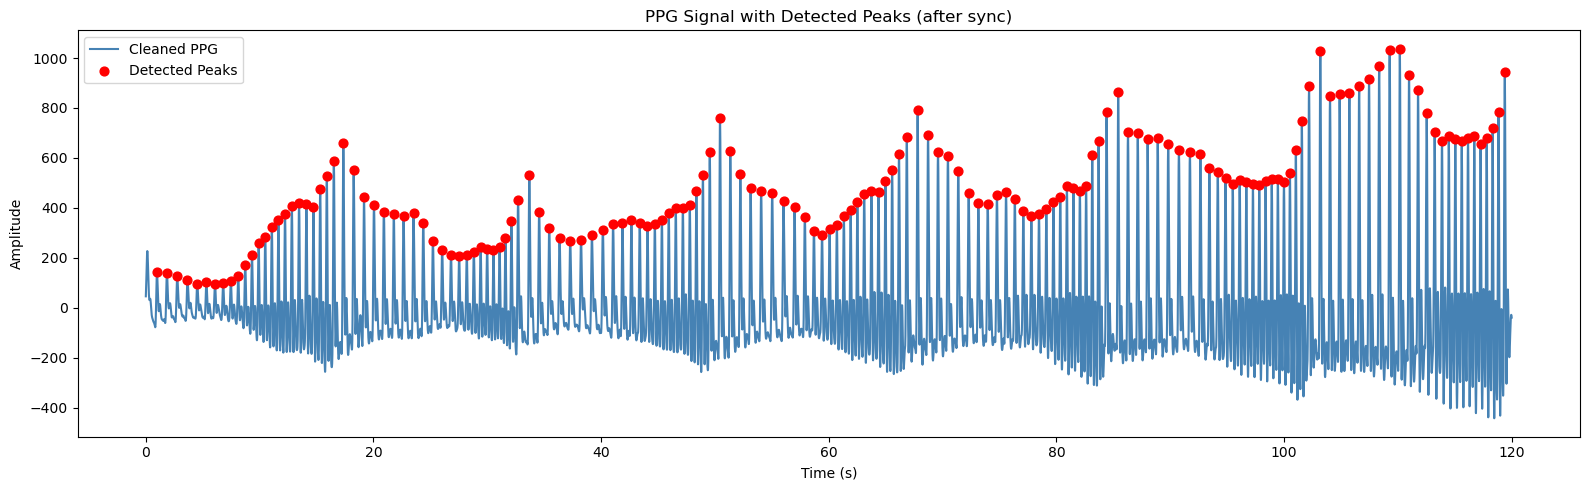

In [4]:
# Process PPG with NeuroKit2
signals_ppg, info_ppg = nk.ppg_process(ppg_trimmed, sampling_rate=PPG_FS)

# Extract peak indices
ppg_peak_indices = np.where(signals_ppg["PPG_Peaks"] == 1)[0]
print(f"PPG peaks detected: {len(ppg_peak_indices)}")

# Plot PPG with detected peaks
ppg_time_trimmed = np.arange(len(ppg_trimmed)) / PPG_FS

plt.figure(figsize=(16, 5))
plt.plot(ppg_time_trimmed, signals_ppg["PPG_Clean"], color='steelblue', label='Cleaned PPG')
plt.scatter(ppg_time_trimmed[ppg_peak_indices], signals_ppg["PPG_Clean"].iloc[ppg_peak_indices],
            color='red', s=40, zorder=5, label='Detected Peaks')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('PPG Signal with Detected Peaks (after sync)')
plt.legend()
plt.tight_layout()
plt.show()

## Process ECG Signal

ECG R-peaks detected: 164


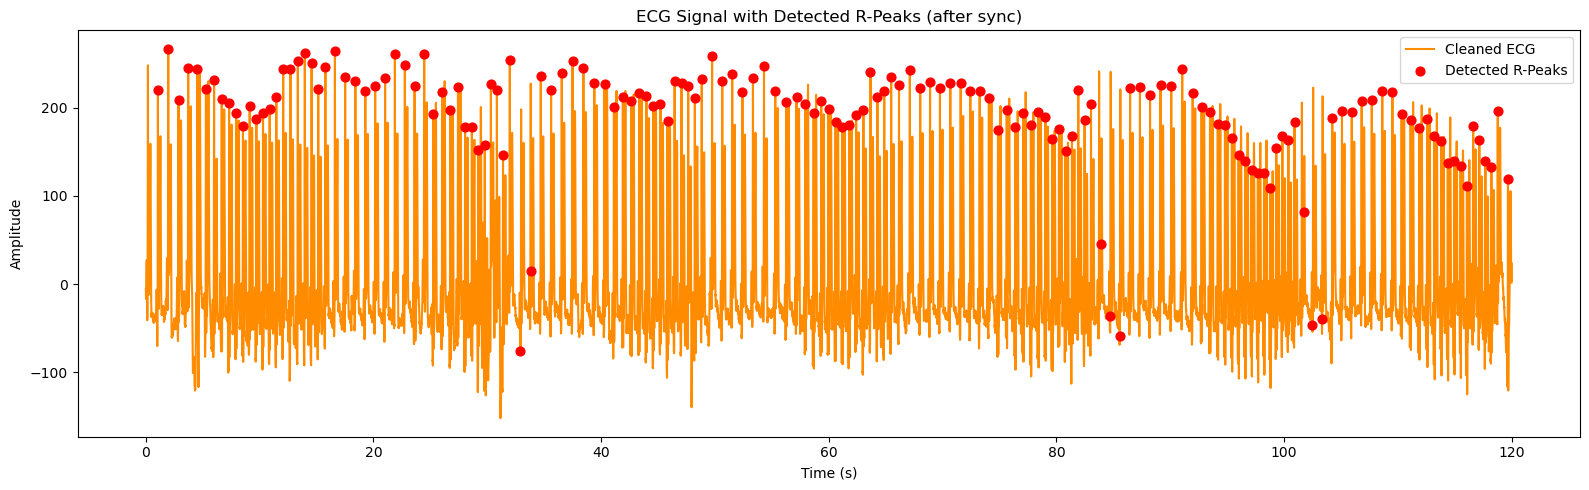

In [5]:
# Process ECG with NeuroKit2
signals_ecg, info_ecg = nk.ecg_process(ecg_trimmed, sampling_rate=ECG_FS)

# Extract R-peak indices
ecg_rpeaks = info_ecg["ECG_R_Peaks"]
print(f"ECG R-peaks detected: {len(ecg_rpeaks)}")

# Plot ECG with detected R-peaks
ecg_time_trimmed = np.arange(len(ecg_trimmed)) / ECG_FS
ecg_clean = signals_ecg["ECG_Clean"]

plt.figure(figsize=(16, 5))
plt.plot(ecg_time_trimmed, ecg_clean, color='darkorange', label='Cleaned ECG')
plt.scatter(ecg_time_trimmed[ecg_rpeaks], ecg_clean.iloc[ecg_rpeaks],
            color='red', s=40, zorder=5, label='Detected R-Peaks')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('ECG Signal with Detected R-Peaks (after sync)')
plt.legend()
plt.tight_layout()
plt.show()

## Calculate RMSSD & Compare

In [6]:
# --- PPG RMSSD ---
# Build a peaks dict for nk.hrv_time (expects a dict with "PPG_Peaks" key containing indices)
ppg_peaks_dict = {"PPG_Peaks": ppg_peak_indices}
hrv_ppg = nk.hrv_time(ppg_peaks_dict, sampling_rate=PPG_FS)
rmssd_ppg = hrv_ppg["HRV_RMSSD"].values[0]

# --- ECG RMSSD ---
ecg_peaks_dict = {"ECG_R_Peaks": ecg_rpeaks}
hrv_ecg = nk.hrv_time(ecg_peaks_dict, sampling_rate=ECG_FS)
rmssd_ecg = hrv_ecg["HRV_RMSSD"].values[0]

# --- Comparison ---
absolute_error = abs(rmssd_ppg - rmssd_ecg)
rmse = np.sqrt((rmssd_ppg - rmssd_ecg) ** 2)  # For a single pair, RMSE = absolute error

print("=" * 50)
print(f"  PPG RMSSD:        {rmssd_ppg:.2f} ms")
print(f"  ECG RMSSD:        {rmssd_ecg:.2f} ms")
print(f"  Absolute Error:   {absolute_error:.2f} ms")
print(f"  RMSE:             {rmse:.2f} ms")
print("=" * 50)

# Summary table
results_df = pd.DataFrame({
    "Source": ["PPG", "ECG"],
    "RMSSD (ms)": [rmssd_ppg, rmssd_ecg],
    "Peaks Detected": [len(ppg_peak_indices), len(ecg_rpeaks)],
    "Duration (s)": [len(ppg_trimmed) / PPG_FS, len(ecg_trimmed) / ECG_FS]
})

error_df = pd.DataFrame({
    "Metric": ["Absolute Error (ms)", "RMSE (ms)"],
    "Value": [absolute_error, rmse]
})

print("\n--- Results ---")
display(results_df)
print("\n--- Error ---")
display(error_df)

  PPG RMSSD:        73.74 ms
  ECG RMSSD:        70.93 ms
  Absolute Error:   2.81 ms
  RMSE:             2.81 ms

--- Results ---


,Source,RMSSD (ms),Peaks Detected,Duration (s)
0,PPG,73.744638,164,120.0
1,ECG,70.930326,164,120.0



--- Error ---


,Metric,Value
0,Absolute Error (ms),2.814312
1,RMSE (ms),2.814312
